### First Look at MIST Simulations

Let's take a first look at our MIST Simulation datafiles. These are organized a bit differently than the BASTI Isochrones we were looking at, so let's see how we can both parse each datafile and append additional useful information we can extrapolate (e.g. stellar radius via Stefan-Boltzmann), et cetera.


Our end goal will be to apply the Kopperapu at al. code for calculating $S_\text{eff}$ and all that (calculating photosynthetic min/max distances, I believe) for given stellar inputs. We'll see, we'll see!

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

#### Introduction

Let's declare the paths to each of our sims. Recall the mass range:

$$M_{\star} \in [0.1 M_{\odot}, 0.25 M_{\odot}, 0.5 M_{\odot}, 1 M_{\odot}, 1.2 M_{\odot}]$$

This will make it easier to open up these datafiles later. Note that, technically, these aren't `csv` (comma-separated value) or `tsv` (tab-separated value) files. That's okay! Filetypes, in the grand scheme of things, are kind-of fake. What I mean by this is that it's (mostly) text files all the way down, regardless of the filetype 'tag'. My point here is that it doesn't matter if we have a `csv` or a `tsv` or a `dat` file, we'll just be able to open it up and look at the text anyway.

In [2]:
mass01 = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0001000M.track.eep"
mass025 = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0002500M.track.eep"
mass05 = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0005000M.track.eep"
mass1 = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0010000M.track.eep"
mass12 = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0012000M.track.eep"

Let's open these up and read each of them. It'll serve us well to convert these into dataframes so that we can add columns, etc., with `pandas`.

In [3]:
# Unfortunately because these are not generic csv/tsv/dat files we have to do a bit of manual labor
def load_mist(filepath):
    colnames = None
    
    # On our first pass we will find the column name line
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') and 'star_age' in line: # This is scrappy. In more formal code we'd want something more robust than the equivalent of control+f-ing something we know is in *this* header. What if a different simulation format (e.g. isochrones from MIST instead of stellar evolution) dont have the same header? 
                # This is the header row with column names
                colnames = line[1:].split()  # remove '#' and split
                break

    if colnames is None:
        raise ValueError("No column header line")

    # Second pass: read data
    df = pd.read_csv(
        filepath,
        comment='#',           # ignore all other header lines
        delim_whitespace=True, # columns are space-separated
        names=colnames
    )

    return df

In [ ]:
mass01  = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0001000M.track.eep"
mass025 = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0002500M.track.eep"
mass05  = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0005000M.track.eep"
mass1   = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0010000M.track.eep"
mass12  = "/Users/anniem/Desktop/School/Research/PHZ_CHLab/MIST_Sims/MIST_MassRange/0012000M.track.eep"

df_01  = load_mist(mass01)
df_025 = load_mist(mass025)
df_05  = load_mist(mass05)
df_1   = load_mist(mass1)
df_12  = load_mist(mass12)

Let's sanity-check and see if this worked...

In [5]:
df_01.head()
df_01.columns
df_01[['star_age', 'log_L', 'log_Teff']].head()

,star_age,log_L,log_Teff
0,60088.350133,-0.797748,3.467689
1,63284.719116,-0.802299,3.467765
2,66651.058656,-0.807022,3.467844
3,70194.471666,-0.811940,3.467926
4,73922.530873,-0.816986,3.468009


Awesome! Let's take a look at all of the columns:

In [6]:
# We'll just use df_01 for display purposes, but note that all of these have the same columns.
print(df_01.columns)

Index(['star_age', 'star_mass', 'star_mdot', 'he_core_mass', 'c_core_mass',
       'o_core_mass', 'log_L', 'log_L_div_Ledd', 'log_LH', 'log_LHe', 'log_LZ',
       'log_Teff', 'log_abs_Lgrav', 'log_R', 'log_g', 'log_surf_z',
       'surf_avg_omega', 'surf_avg_v_rot', 'surf_num_c12_div_num_o16',
       'v_wind_Km_per_s', 'surf_avg_omega_crit',
       'surf_avg_omega_div_omega_crit', 'surf_avg_v_crit',
       'surf_avg_v_div_v_crit', 'surf_avg_Lrad_div_Ledd', 'v_div_csound_surf',
       'surface_h1', 'surface_he3', 'surface_he4', 'surface_li7',
       'surface_be9', 'surface_b11', 'surface_c12', 'surface_c13',
       'surface_n14', 'surface_o16', 'surface_f19', 'surface_ne20',
       'surface_na23', 'surface_mg24', 'surface_si28', 'surface_s32',
       'surface_ca40', 'surface_ti48', 'surface_fe56', 'log_center_T',
       'log_center_Rho', 'center_degeneracy', 'center_omega', 'center_gamma',
       'mass_conv_core', 'center_h1', 'center_he4', 'center_c12', 'center_n14',
       'center_o16

#### Basic Plots

Neat--it looks like this data actually already has $R$ (meaning $R_{\star}$) in it already, so we don't need to use the Stefan-Boltzmann relation to figure that out like we did with the BASTI Sims.

Now recall what we were working on with the BASTI Sims--the first plots we generated were of:
- log(t(yr)) vs. log(L/Lo)
- log(t(yr)) vs. logTe
- log(t(yr)) vs. M/Mo
- and log(t(yr)) vs. [M/H], but I don't care to plot this so let's plot stellar radius instead (since we have that column!)

So let's start with re-creating those. We can then try and tackle the HZ calculation (with $S_{\text{eff}}$ and all that jazz).

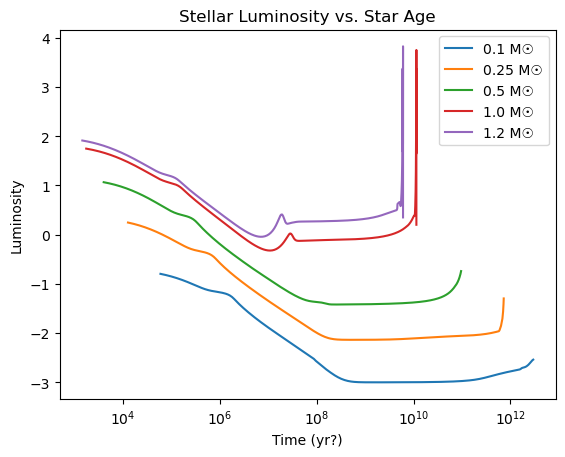

In [7]:
# Plotting luminosity vs time:
plt.plot(df_01['star_age'], df_01['log_L'], label='0.1 M☉')
plt.plot(df_025['star_age'], df_025['log_L'], label='0.25 M☉')
plt.plot(df_05['star_age'], df_05['log_L'], label='0.5 M☉')
plt.plot(df_1['star_age'], df_1['log_L'], label='1.0 M☉')
plt.plot(df_12['star_age'], df_12['log_L'], label='1.2 M☉')
plt.xlabel('Time (yr?)') # idk if this is actually in years lol
plt.xscale('log')
plt.ylabel('Luminosity')
#plt.yscale('log')
plt.legend()
plt.title('Stellar Luminosity vs. Star Age')
plt.show()

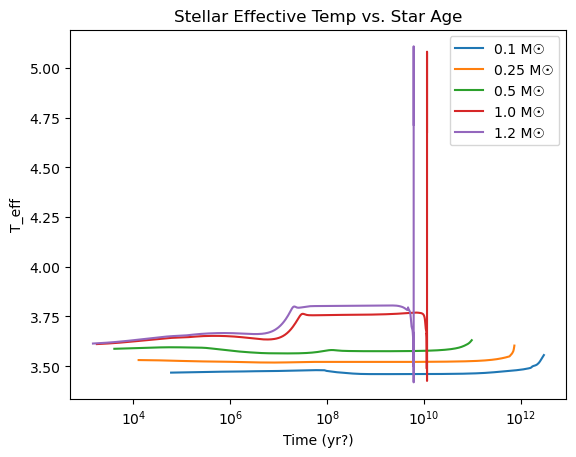

In [8]:
# Plotting temp vs time:
plt.plot(df_01['star_age'], df_01['log_Teff'], label='0.1 M☉')
plt.plot(df_025['star_age'], df_025['log_Teff'], label='0.25 M☉')
plt.plot(df_05['star_age'], df_05['log_Teff'], label='0.5 M☉')
plt.plot(df_1['star_age'], df_1['log_Teff'], label='1.0 M☉')
plt.plot(df_12['star_age'], df_12['log_Teff'], label='1.2 M☉')
plt.xlabel('Time (yr?)') # idk if this is actually in years lol
plt.xscale('log')
plt.ylabel('T_eff')
#plt.yscale('log')
plt.legend()
plt.title('Stellar Effective Temp vs. Star Age')
plt.show()

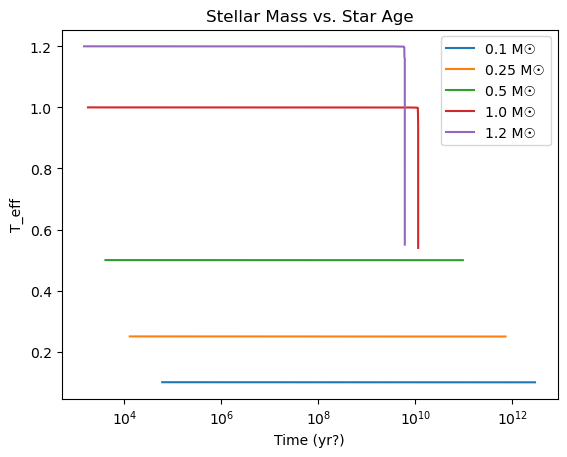

In [9]:
# Plotting mass vs time:
plt.plot(df_01['star_age'], df_01['star_mass'], label='0.1 M☉')
plt.plot(df_025['star_age'], df_025['star_mass'], label='0.25 M☉')
plt.plot(df_05['star_age'], df_05['star_mass'], label='0.5 M☉')
plt.plot(df_1['star_age'], df_1['star_mass'], label='1.0 M☉')
plt.plot(df_12['star_age'], df_12['star_mass'], label='1.2 M☉')
plt.xlabel('Time (yr?)') # idk if this is actually in years lol
plt.xscale('log')
plt.ylabel('T_eff')
#plt.yscale('log')
plt.legend()
plt.title('Stellar Mass vs. Star Age')
plt.show()

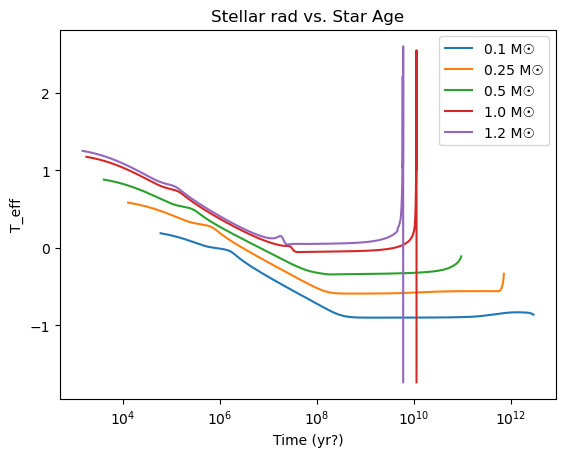

In [10]:
# Plotting rad vs time:
plt.plot(df_01['star_age'], df_01['log_R'], label='0.1 M☉')
plt.plot(df_025['star_age'], df_025['log_R'], label='0.25 M☉')
plt.plot(df_05['star_age'], df_05['log_R'], label='0.5 M☉')
plt.plot(df_1['star_age'], df_1['log_R'], label='1.0 M☉')
plt.plot(df_12['star_age'], df_12['log_R'], label='1.2 M☉')
plt.xlabel('Time (yr?)') # idk if this is actually in years lol
plt.xscale('log')
plt.ylabel('T_eff')
#plt.yscale('log')
plt.legend()
plt.title('Stellar rad vs. Star Age')
plt.show()

#### Calculating HZ Distances

Let's see if we can repurpose the Kopperapu code we used for calculating Habitable Zones via the $S_{\text{eff}}$ polynomial for these data... [Here's the code](https://personal.ems.psu.edu/~jfk4/ruk15//planets/hzcalc.py) we're referencing.

We'll start by re-introducing our coefficients, the same ones from Kopparapu...

In [11]:
# Coeffs
seffsun  = np.array([1.776, 1.107, 0.356, 0.320, 1.188, 0.99])
a = np.array([2.136e-4, 1.332e-4, 6.171e-5, 5.547e-5, 1.433e-4, 1.209e-4])
b = np.array([2.533e-8, 1.580e-8, 1.698e-9, 1.526e-9, 1.707e-8, 1.404e-8])
c = np.array([-1.332e-11, -8.308e-12, -3.198e-12, -2.874e-12, -8.968e-12, -7.418e-12])
d = np.array([-3.097e-15, -1.931e-15, -5.575e-16, -5.011e-16, -2.084e-15, -1.713e-15])

hz_labels = [
    "Recent Venus",        # 0  optimistic inner
    "Runaway Greenhouse",  # 1  conservative inner
    "Maximum Greenhouse",  # 2  conservative outer
    "Early Mars",          # 3  optimistic outer
    "5ME Runaway",         # 4
    "0.1ME Runaway"        # 5
]

def add_cols(df):
    # Here we'll add columns for Teff, L/Lsun, and HZ distances to our dataframes.
    # This is dependent on the DFs having columns 'star_age', 'log_L', and 'log_Teff'.

    out = df.copy()

    # Unlog
    out["Teff_K"] = 10**out["log_Teff"].to_numpy()
    out["L_over_Lsun"] = 10**out["log_L"].to_numpy()

    # Kopparapu polynomial uses Tstar = Teff - 5780 K... wasn't sure what we decided to do here
    Tstar = out["Teff_K"] - 5780.0

    for i, label in enumerate(hz_labels):
        Seff = seffsun[i] + a[i]*Tstar + b[i]*Tstar**2 + c[i]*Tstar**3 + d[i]*Tstar**4
        Seff = np.where(Seff > 0, Seff, np.nan)  # guard against negative or zero Seff

        col_dist = f"d_AU_{label.replace(' ','_')}"
        out[col_dist] = np.sqrt(out["L_over_Lsun"] / Seff)

    return out


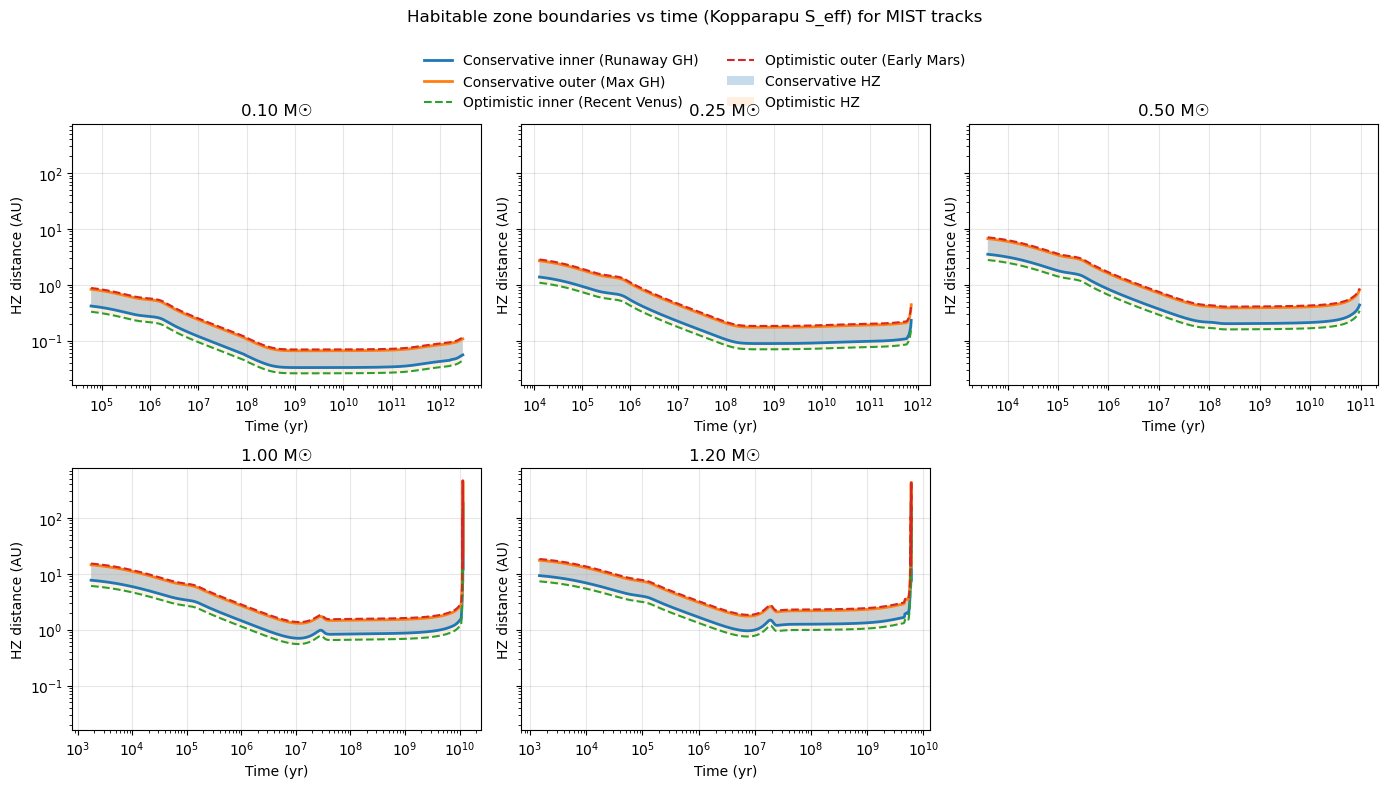

In [12]:
# Now we build a dict of the already-loaded DFs...
tracks = {
    "0.10 M☉": df_01,
    "0.25 M☉": df_025,
    "0.50 M☉": df_05,
    "1.00 M☉": df_1,
    "1.20 M☉": df_12,
}

# And add the HZ columns...
tracks_hz = {k: add_cols(v) for k, v in tracks.items()}

# And we can plot this stuff out 
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False, sharey=True)
axes = axes.ravel()

for ax, (label, df) in zip(axes, tracks_hz.items()):
    t = df["star_age"].to_numpy()

    d_con_in  = df["d_AU_Runaway_Greenhouse"].to_numpy()
    d_con_out = df["d_AU_Maximum_Greenhouse"].to_numpy()
    d_opt_in  = df["d_AU_Recent_Venus"].to_numpy()
    d_opt_out = df["d_AU_Early_Mars"].to_numpy()

    # mask finite values
    m_con = np.isfinite(t) & np.isfinite(d_con_in) & np.isfinite(d_con_out)
    m_opt = np.isfinite(t) & np.isfinite(d_opt_in) & np.isfinite(d_opt_out)

    # boundaries
    ax.semilogx(t[m_con], d_con_in[m_con],  lw=2, label="Conservative inner (Runaway GH)")
    ax.semilogx(t[m_con], d_con_out[m_con], lw=2, label="Conservative outer (Max GH)")
    ax.semilogx(t[m_opt], d_opt_in[m_opt],  lw=1.5, ls="--", label="Optimistic inner (Recent Venus)")
    ax.semilogx(t[m_opt], d_opt_out[m_opt], lw=1.5, ls="--", label="Optimistic outer (Early Mars)")

    # fills
    ax.fill_between(t[m_con], d_con_in[m_con], d_con_out[m_con], alpha=0.25, label="Conservative HZ")
    ax.fill_between(t[m_opt], d_opt_in[m_opt], d_opt_out[m_opt], alpha=0.12, label="Optimistic HZ")

    ax.set_title(label)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.set_xlabel("Time (yr)")
    ax.set_ylabel("HZ distance (AU)")

# We only have five tracks we're plotting, so turn off the last axis
axes[-1].axis("off")

# And create one legend for the entire figure. Knowing how to use MatPlotLib is half the battle here really
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),  # <— this was overlapping w the tilte when i first tried
    ncol=2,
    frameon=False
)

fig.suptitle("Habitable zone boundaries vs time (Kopparapu S_eff) for MIST tracks", y=0.98) # add some more spacing perhaps...
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()


### The Photosynthetic Zone

The expression below gives the chlorophyll *a*-normalized net photosynthetic rate as a function of irradiance intensity, I:

$$P(I) = \frac{I}{\alpha I^2 + \beta I + \gamma} - P_{\text{rate}}^{\text{max}} R_{\text{rate}}$$

Where we define:

$$P_{\text{rate}}^{\text{max}} = \frac{1}{\beta + 2 \sqrt{\alpha \gamma}}$$

And:

$$I = f_{a} \cdot \frac{\dot{N_{\star}}}{4 \pi a^2}$$

Where, in *this* expression (the light intensity at the bottom of the atmosphere), we may express (note the extra factor of $\pi$):

$$\dot{N}_{\star} = 4 \pi^2 R_{\star}^2 \int _{\lambda_{\text{min}}} ^{\lambda_{\text{max}}} \frac{2c}{\lambda^4} \left[ \text{exp} \left( \frac{hc}{\lambda k_{B} T} \right) - 1 \right]^{-1} d \lambda $$

We are trying to find the *boundaries* of the photosynthetic zone--in other words, the inner and outer edge where $P(I) = 0$. So, in essence, we need to just find the zeroes of that function and solve for $a$ in $I$.

This is easier said than done, because we have (1) a whole bunch of constants, (2) a whole bunch of permutations over those constants, (3) a whole bunch of different stellar masses we're evaluating that equation for, and (4) a whole bunch of equations to wrangle in general. So... let's try and do this step by step.

**Our Constants**

The parameters in our equations for $P(I)$ and $P_{\text{max}}^{\text{rate}}$ aren't unknowns; we have these values! Let's make note of what we should be substituting in here. These are given by Hall 2023:

- $\alpha = 1.0 \times 10^{-5}$
- $\beta = 1.0 \times 10^{-3}$
- $\gamma = 2.0$

These have something to do with the photosynthesis rate curves of phytoplankton, evaluated in a lab setting.

We also have three different values of $R_{\text{rate}}$, given by Hall 2023:

- $R_{\text{rate}} = 0.3$
- $R_{\text{rate}} = 0.6$
- $R_{\text{rate}} = 0.8$

And, for $f_{a}$:

- $f_a = 1.0$
- $f_a = 0.6$
- $f_a = 0.2$

With $\lambda \in [400 \text{nm}, 700 \text{nm}]$ for $\dot{N}_{\star}$


In [13]:
from scipy.integrate import quad # integration stuff

# CONSTANTS
h_planck = 6.626e-34    # Planck constant 
c_light  = 3.0e8        # speed of light 
k_B      = 1.381e-23    # Boltzmann constant 
N_A      = 6.022e23     # Avogadro's number
R_sun_m  = 6.957e8      # solar radius [m]
AU_m     = 1.496e11     # 1 AU [m]

# #BOUNDS
lam_min = 400e-9   # 400 nm [m]
lam_max = 700e-9   # 700 nm [m]

# These are fit to lab P-I curves where I is in MICROMOL PHOTONS/(METERS^2 * SECONDS) !!! UNITS!!!
alpha_p = 1.0e-5
beta_p  = 1.0e-3
gamma_p = 2.0

# Parameter grids from Dr Hall
R_rates = [0.3, 0.6, 0.8]          # respiration as fraction of P_max
f_as    = [1.0, 0.6, 0.2]          # atmospheric attenuation factors
R_rate_labels = ["Excellent", "Optimistic", "Pessimistic"]


**Step 1:** Compute $P_{\text{rate}}^{\text{max}}$ and find the critical irradiances $I_{\text{crit}}$ where $P(I) = 0$.

Setting $P(I) = 0$ gives us:

$$\frac{I}{\alpha I^2 + \beta I + \gamma} = P_{\text{max}} \cdot R_{\text{rate}}$$

Let $k = P_{\text{max}} \cdot R_{\text{rate}}$. Rearranging:

$$k\alpha \, I^2 + (k\beta - 1) \, I + k\gamma = 0$$

This is a quadratic in $I$! The two roots give us the inner ($\therefore$ high $I$, close to star) and outer (low $I$, far from star) photosynthesis zone boundaries.


In [14]:
# Maximum photosynthetic rate (Eq. 6 from Hall 2023)
P_max = 1.0 / (beta_p + 2.0 * np.sqrt(alpha_p * gamma_p))
print(f"P_max = {P_max:.4f}")

def find_I_crit(R_rate):
    k = P_max * R_rate
    
    # Quadratic coefficients: A * I^2 + B*I + C = 0
    A = k * alpha_p
    B = k * beta_p - 1.0
    C = k * gamma_p
    
    discriminant = B**2 - 4*A*C
    if discriminant < 0:
        return np.nan, np.nan  # no real roots = no photosynthesis zone :(
    
    sqrt_disc = np.sqrt(discriminant)
    I_inner = (-B + sqrt_disc) / (2*A)   # larger root (closer to star == more light)
    I_outer = (-B - sqrt_disc) / (2*A)   # smaller root (farther from star == less light)
    
    return I_outer, I_inner

# Sanity check-- we shld print the critical irradiances for each R_rate
for R_rate, label in zip(R_rates, R_rate_labels):
    I_out, I_in = find_I_crit(R_rate)
    print(f"{label} (R_rate={R_rate}):  I_outer = {I_out:.1f},  I_inner = {I_in:.1f}")


P_max = 100.5604
Excellent (R_rate=0.3):  I_outer = 63.5,  I_inner = 3151.3
Optimistic (R_rate=0.6):  I_outer = 141.2,  I_inner = 1416.2
Pessimistic (R_rate=0.8):  I_outer = 215.7,  I_inner = 927.4


**Step 2:** Compute $\dot{N}_{\star}$, the total photon emission rate in the PAR band.

The integrand is the **photon** spectral radiance — we get it by dividing the Planck function $B_\lambda$ by the energy per photon $hc/\lambda$:

$$\frac{B_\lambda}{hc/\lambda} = \frac{2c}{\lambda^4} \left[ \exp\left(\frac{hc}{\lambda k_B T}\right) - 1 \right]^{-1}$$

Then (Hall Eq. 9): $\quad \dot{N}_{\star} = 4\pi^2 R_{\star}^2 \int_{400\text{nm}}^{700\text{nm}} (\text{stuff above}) d\lambda \quad$[photons/s]


In [15]:
def photon_integrand(lam, T):
    exponent = h_planck * c_light / (lam * k_B * T)
    return (2.0 * c_light / lam**4) / (np.exp(exponent) - 1.0)

def compute_Ndot(T_eff, R_star_m):
    integral_val, _ = quad(photon_integrand, lam_min, lam_max, args=(T_eff,))
    Ndot = 4.0 * np.pi**2 * R_star_m**2 * integral_val
    return Ndot

# Quick sanity check with the Sun
Ndot_sun = compute_Ndot(5780, R_sun_m)
print(f"N dot sun (PAR) = {Ndot_sun:.3e} photons/s") # does this look right?


N dot sun (PAR) = 3.877e+44 photons/s


**Step 3:** Convert critical irradiance to orbital distance.

From Hall Eq. 11: $\quad I = f_a \cdot \dfrac{\dot{N}_{\star}}{4\pi a^2}$

But $I$ in this formula is in $\text{photons}/(s \cdot m^2)$, while our $I_{\text{crit}}$ from the P–I curve is in $\mu \text{mol} / (s \cdot m^2)$... So we need a unit conversion:

$$I = \frac{\dot{N}_{\star}}{4\pi a^2} \cdot \frac{10^6}{N_A} \cdot f_a$$

Solving for $a$:

$$a = \sqrt{\frac{f_a \cdot \dot{N}_{\star} \cdot 10^6}{4\pi \cdot I_{\text{crit}} \cdot N_A}}$$


In [16]:
def Icrit_to_distance_AU(Ndot, I_crit, f_a):
    a_meters = np.sqrt(f_a * Ndot * 1e6 / (4.0 * np.pi * I_crit * N_A))
    a_AU = a_meters / AU_m
    return a_AU

# Sanity check: Earth PAR irradiance should be ~2000-ish
I_earth = f_as[0] * Ndot_sun * 1e6 / (4 * np.pi * AU_m**2 * N_A)  # no attenuation, 1 AU
print(f"PAR photon flux at Earth (f_a=1): {I_earth:.0f}")

PAR photon flux at Earth (f_a=1): 2289


**Step 4:** Loop over each MIST track and compute $\dot{N}_{\star}$ at every timestep, then get the inner/outer PZ distances for each $(f_a, R_{\text{rate}})$ combo.


In [ ]:
def add_phz_cols(df):
    out = df.copy()
    
    T_eff    = out["Teff_K"].to_numpy()
    R_star_m = 10**out["log_R"].to_numpy() * R_sun_m   # physical radius in meters
    
    # Compute Ndot_star at each timestep 
    Ndot = np.array([compute_Ndot(T, R) for T, R in zip(T_eff, R_star_m)])
    out["Ndot"] = Ndot
    
    # For each (f_a, R_rate), convert critical I to distance
    for f_a in f_as:
        for R_rate in R_rates:
            I_out, I_in = find_I_crit(R_rate)
            tag = f"fa{f_a}_Rr{R_rate}"
            
            if np.isnan(I_out) or np.isnan(I_in):
                out[f"PHZ_inner_{tag}"] = np.nan
                out[f"PHZ_outer_{tag}"] = np.nan
            else:
                # Vectorized: Icrit_to_distance_AU works element-wise on Ndot array
                out[f"PHZ_inner_{tag}"] = Icrit_to_distance_AU(Ndot, I_in, f_a)
                out[f"PHZ_outer_{tag}"] = Icrit_to_distance_AU(Ndot, I_out, f_a)
    
    return out

# Apply to all tracks
tracks_phz = {}
for label, df in tracks_hz.items():
    tracks_phz[label] = add_phz_cols(df)


**Step 5:** Plot the photosynthetic habitable zone for the 1.0 $M_\odot$ track.

We'll make a 3x3 grid, somewhat mirroring Figure 2 from Hall 2023...
- **Rows** --> atmospheric attenuation ($f_a$): 1.0, 0.6, 0.2
- **Columns** --> quality of conditions ($R_{\text{rate}}$): 0.3 (Excellent), 0.6 (Optimistic), 0.8 (Pessimistic)



<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/3162651547.py:44: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/3162651547.py:54: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle("Photosynthetic Habitable Zone — 1.0 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)


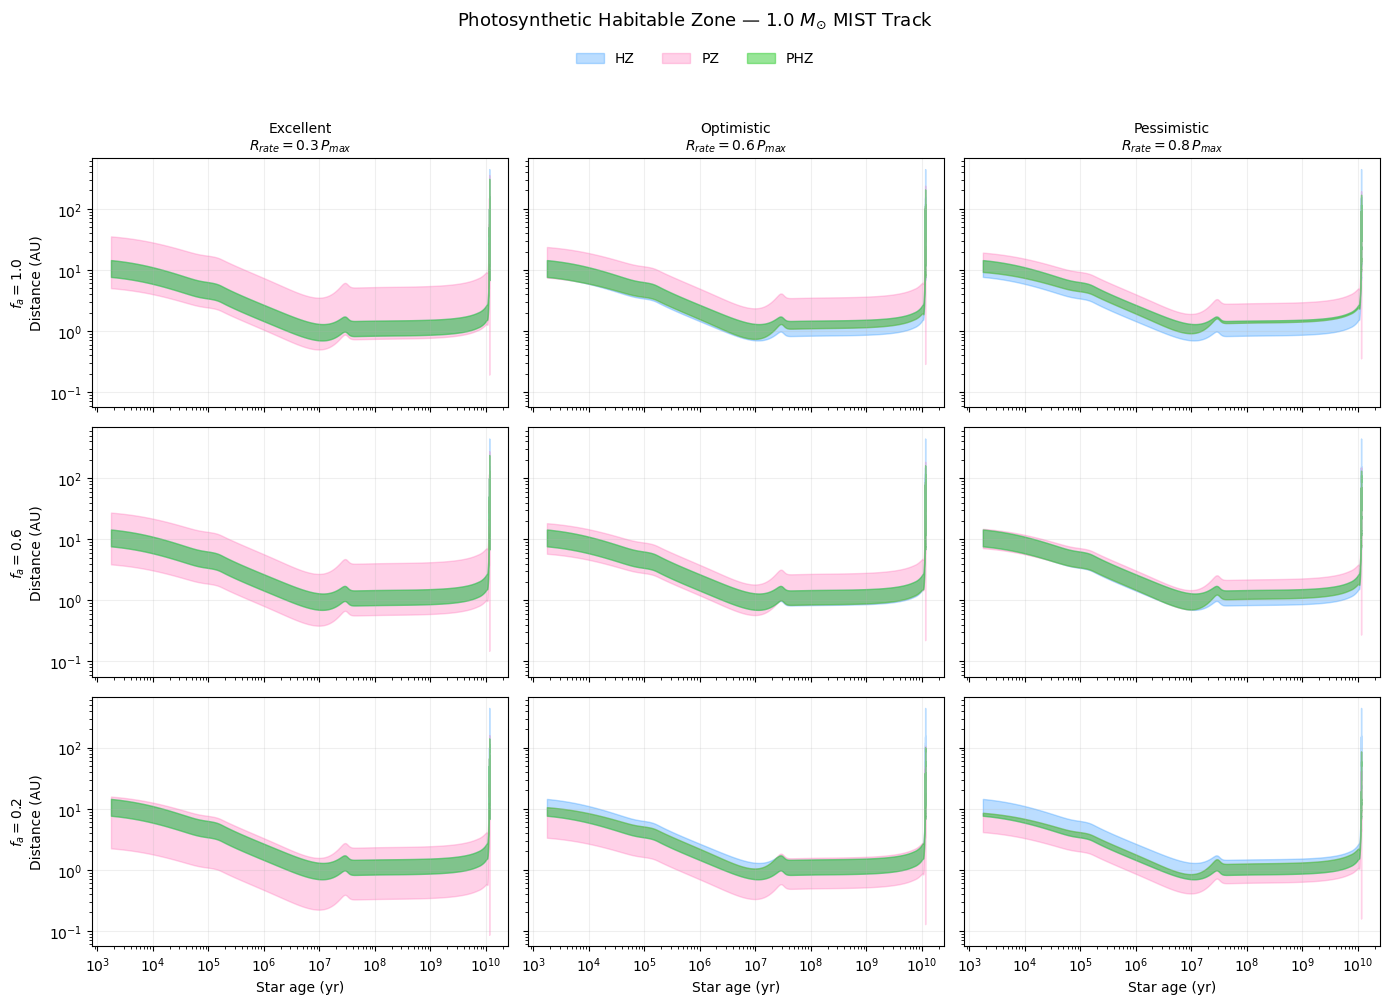

In [18]:
df_plot = tracks_phz["1.00 M☉"] # just doing this one track for now
t = df_plot["star_age"].to_numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for row, f_a in enumerate(f_as):
    for col, (R_rate, rlabel) in enumerate(zip(R_rates, R_rate_labels)):
        ax = axes[row, col]
        tag = f"fa{f_a}_Rr{R_rate}"
        
        #  HZ boundaries (conservative: Runaway GH inner, Max GH outer) 
        hz_in  = df_plot["d_AU_Runaway_Greenhouse"].to_numpy()
        hz_out = df_plot["d_AU_Maximum_Greenhouse"].to_numpy()
        
        #  PZ boundaries 
        pz_in  = df_plot[f"PHZ_inner_{tag}"].to_numpy()
        pz_out = df_plot[f"PHZ_outer_{tag}"].to_numpy()
        
        #  Overlap (PHZ) = max of inner edges to min of outer edges 
        phz_in  = np.maximum(hz_in, pz_in)
        phz_out = np.minimum(hz_out, pz_out)
        # Only valid where inner < outer
        overlap_mask = phz_in < phz_out
        
        # Masks for finite values
        m = np.isfinite(t) & np.isfinite(hz_in) & np.isfinite(hz_out)
        mp = np.isfinite(t) & np.isfinite(pz_in) & np.isfinite(pz_out)
        
        # Plot fills
        ax.fill_between(t[m],  hz_in[m],  hz_out[m],  color="dodgerblue", alpha=0.3, label="HZ")
        ax.fill_between(t[mp], pz_in[mp], pz_out[mp], color="hotpink",    alpha=0.3, label="PZ")
        
        # PHZ overlap
        mo = m & mp & overlap_mask
        if mo.any():
            ax.fill_between(t[mo], phz_in[mo], phz_out[mo], color="limegreen", alpha=0.5, label="PHZ")
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(alpha=0.2)
        
        # Labels on edges only
        if row == 0:
            ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
        if row == 2:
            ax.set_xlabel("Star age (yr)")
        if col == 0:
            ax.set_ylabel(f"$f_a = {f_a}$\nDistance (AU)", fontsize=10)

# Grab legend from one panel
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=3, frameon=False)

fig.suptitle("Photosynthetic Habitable Zone — 1.0 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


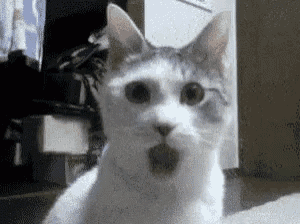

it worked!

<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/755591040.py:44: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/755591040.py:54: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle("Photosynthetic Habitable Zone — 0.1 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)


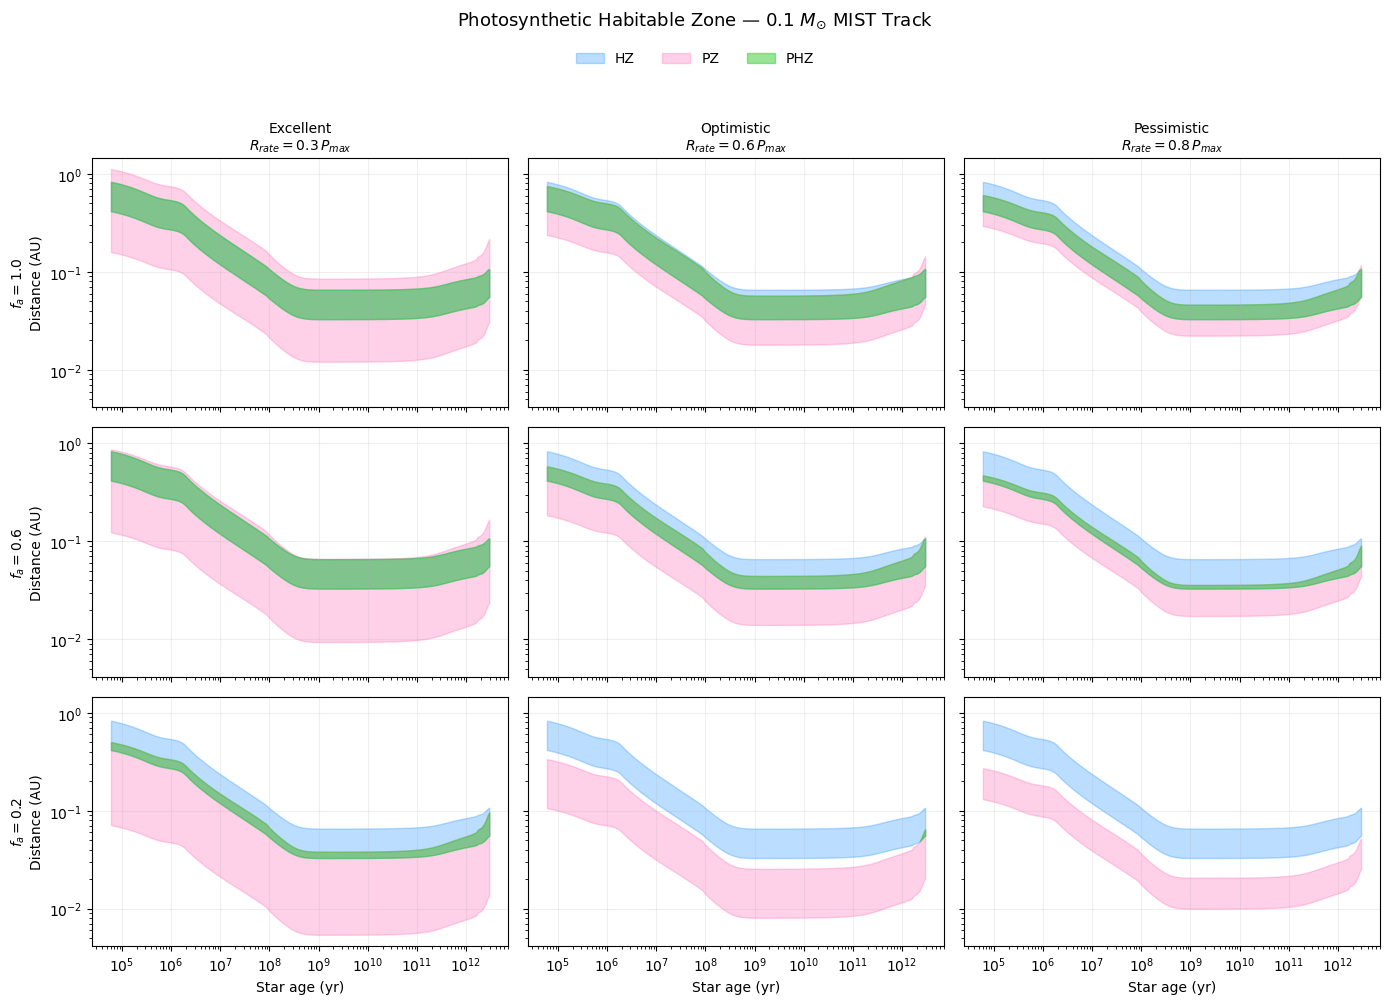

In [19]:
df_plot = tracks_phz["0.10 M☉"]
t = df_plot["star_age"].to_numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for row, f_a in enumerate(f_as):
    for col, (R_rate, rlabel) in enumerate(zip(R_rates, R_rate_labels)):
        ax = axes[row, col]
        tag = f"fa{f_a}_Rr{R_rate}"
        
        #  HZ boundaries (conservative: Runaway GH inner, Max GH outer) 
        hz_in  = df_plot["d_AU_Runaway_Greenhouse"].to_numpy()
        hz_out = df_plot["d_AU_Maximum_Greenhouse"].to_numpy()
        
        #  PZ boundaries 
        pz_in  = df_plot[f"PHZ_inner_{tag}"].to_numpy()
        pz_out = df_plot[f"PHZ_outer_{tag}"].to_numpy()
        
        #  Overlap (PHZ) = max of inner edges to min of outer edges 
        phz_in  = np.maximum(hz_in, pz_in)
        phz_out = np.minimum(hz_out, pz_out)
        # Only valid where inner < outer
        overlap_mask = phz_in < phz_out
        
        # Masks for finite values
        m = np.isfinite(t) & np.isfinite(hz_in) & np.isfinite(hz_out)
        mp = np.isfinite(t) & np.isfinite(pz_in) & np.isfinite(pz_out)
        
        # Plot fills
        ax.fill_between(t[m],  hz_in[m],  hz_out[m],  color="dodgerblue", alpha=0.3, label="HZ")
        ax.fill_between(t[mp], pz_in[mp], pz_out[mp], color="hotpink",    alpha=0.3, label="PZ")
        
        # PHZ overlap
        mo = m & mp & overlap_mask
        if mo.any():
            ax.fill_between(t[mo], phz_in[mo], phz_out[mo], color="limegreen", alpha=0.5, label="PHZ")
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(alpha=0.2)
        
        # Labels on edges only
        if row == 0:
            ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
        if row == 2:
            ax.set_xlabel("Star age (yr)")
        if col == 0:
            ax.set_ylabel(f"$f_a = {f_a}$\nDistance (AU)", fontsize=10)

# Grab legend from one panel
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=3, frameon=False)

fig.suptitle("Photosynthetic Habitable Zone — 0.1 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/295186648.py:44: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/295186648.py:54: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle("Photosynthetic Habitable Zone — 0.25 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)


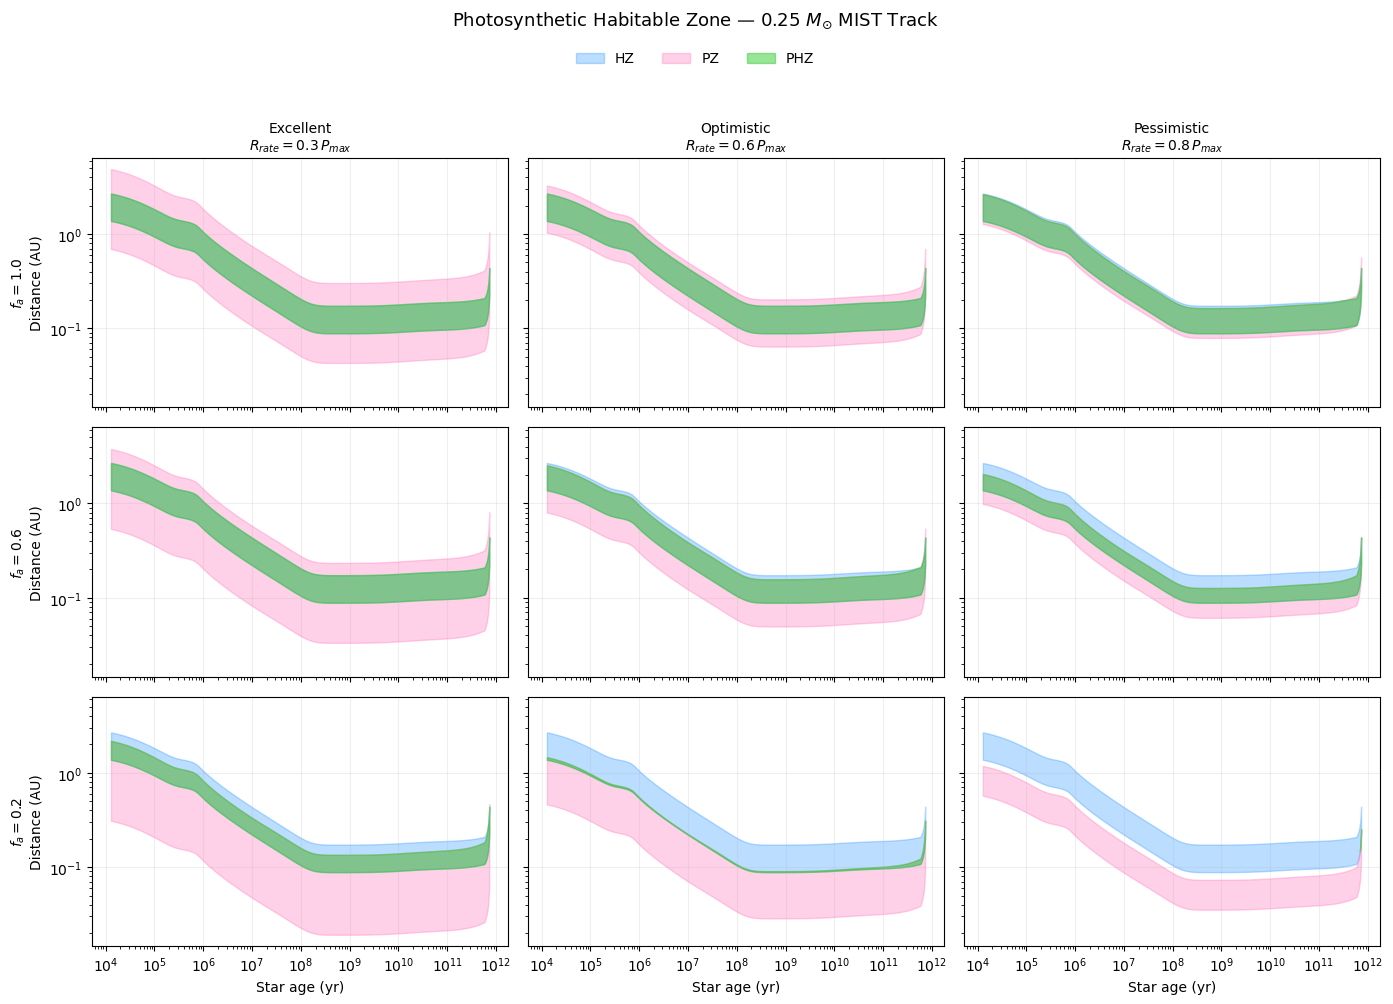

In [20]:
df_plot = tracks_phz["0.25 M☉"] 
t = df_plot["star_age"].to_numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for row, f_a in enumerate(f_as):
    for col, (R_rate, rlabel) in enumerate(zip(R_rates, R_rate_labels)):
        ax = axes[row, col]
        tag = f"fa{f_a}_Rr{R_rate}"
        
        #  HZ boundaries (conservative: Runaway GH inner, Max GH outer) 
        hz_in  = df_plot["d_AU_Runaway_Greenhouse"].to_numpy()
        hz_out = df_plot["d_AU_Maximum_Greenhouse"].to_numpy()
        
        #  PZ boundaries 
        pz_in  = df_plot[f"PHZ_inner_{tag}"].to_numpy()
        pz_out = df_plot[f"PHZ_outer_{tag}"].to_numpy()
        
        #  Overlap (PHZ) = max of inner edges to min of outer edges 
        phz_in  = np.maximum(hz_in, pz_in)
        phz_out = np.minimum(hz_out, pz_out)
        # Only valid where inner < outer
        overlap_mask = phz_in < phz_out
        
        # Masks for finite values
        m = np.isfinite(t) & np.isfinite(hz_in) & np.isfinite(hz_out)
        mp = np.isfinite(t) & np.isfinite(pz_in) & np.isfinite(pz_out)
        
        # Plot fills
        ax.fill_between(t[m],  hz_in[m],  hz_out[m],  color="dodgerblue", alpha=0.3, label="HZ")
        ax.fill_between(t[mp], pz_in[mp], pz_out[mp], color="hotpink",    alpha=0.3, label="PZ")
        
        # PHZ overlap
        mo = m & mp & overlap_mask
        if mo.any():
            ax.fill_between(t[mo], phz_in[mo], phz_out[mo], color="limegreen", alpha=0.5, label="PHZ")
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(alpha=0.2)
        
        # Labels on edges only
        if row == 0:
            ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
        if row == 2:
            ax.set_xlabel("Star age (yr)")
        if col == 0:
            ax.set_ylabel(f"$f_a = {f_a}$\nDistance (AU)", fontsize=10)

# Grab legend from one panel
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=3, frameon=False)

fig.suptitle("Photosynthetic Habitable Zone — 0.25 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/3193050917.py:44: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/3193050917.py:54: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle("Photosynthetic Habitable Zone — 0.50 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)


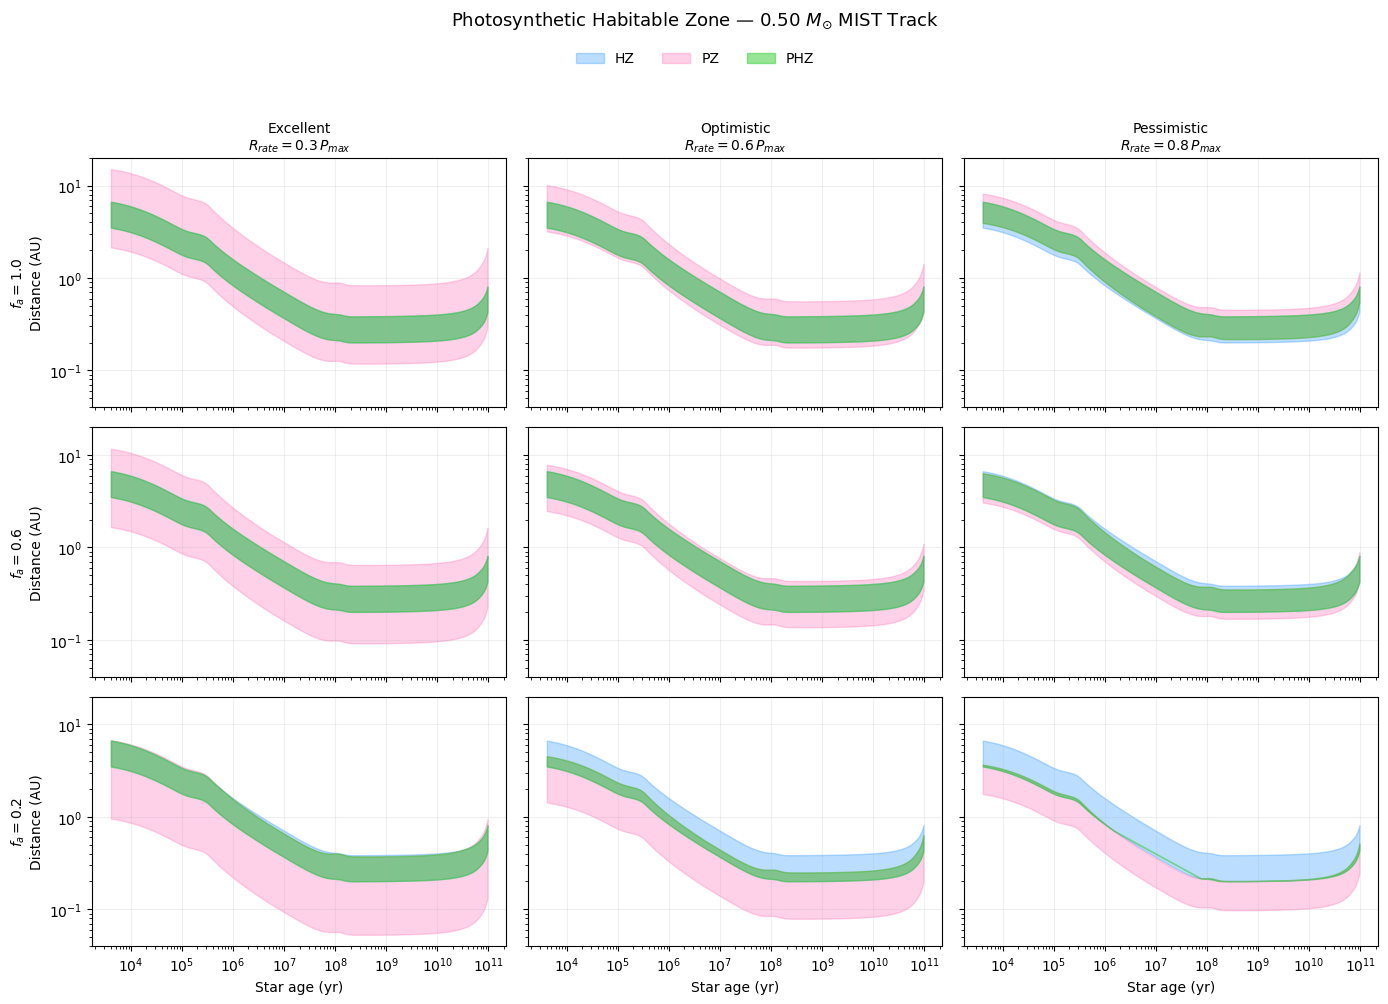

In [21]:
df_plot = tracks_phz["0.50 M☉"] 
t = df_plot["star_age"].to_numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for row, f_a in enumerate(f_as):
    for col, (R_rate, rlabel) in enumerate(zip(R_rates, R_rate_labels)):
        ax = axes[row, col]
        tag = f"fa{f_a}_Rr{R_rate}"
        
        #  HZ boundaries (conservative: Runaway GH inner, Max GH outer) 
        hz_in  = df_plot["d_AU_Runaway_Greenhouse"].to_numpy()
        hz_out = df_plot["d_AU_Maximum_Greenhouse"].to_numpy()
        
        #  PZ boundaries 
        pz_in  = df_plot[f"PHZ_inner_{tag}"].to_numpy()
        pz_out = df_plot[f"PHZ_outer_{tag}"].to_numpy()
        
        #  Overlap (PHZ) = max of inner edges to min of outer edges 
        phz_in  = np.maximum(hz_in, pz_in)
        phz_out = np.minimum(hz_out, pz_out)
        # Only valid where inner < outer
        overlap_mask = phz_in < phz_out
        
        # Masks for finite values
        m = np.isfinite(t) & np.isfinite(hz_in) & np.isfinite(hz_out)
        mp = np.isfinite(t) & np.isfinite(pz_in) & np.isfinite(pz_out)
        
        # Plot fills
        ax.fill_between(t[m],  hz_in[m],  hz_out[m],  color="dodgerblue", alpha=0.3, label="HZ")
        ax.fill_between(t[mp], pz_in[mp], pz_out[mp], color="hotpink",    alpha=0.3, label="PZ")
        
        # PHZ overlap
        mo = m & mp & overlap_mask
        if mo.any():
            ax.fill_between(t[mo], phz_in[mo], phz_out[mo], color="limegreen", alpha=0.5, label="PHZ")
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(alpha=0.2)
        
        # Labels on edges only
        if row == 0:
            ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
        if row == 2:
            ax.set_xlabel("Star age (yr)")
        if col == 0:
            ax.set_ylabel(f"$f_a = {f_a}$\nDistance (AU)", fontsize=10)

# Grab legend from one panel
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=3, frameon=False)

fig.suptitle("Photosynthetic Habitable Zone — 0.50 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:54: SyntaxWarning: invalid escape sequence '\o'
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/2250642415.py:44: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
/var/folders/z1/m_wgbntj7d15ryf7yvl_56kc0000gn/T/ipykernel_97613/2250642415.py:54: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle("Photosynthetic Habitable Zone — 1.20 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)


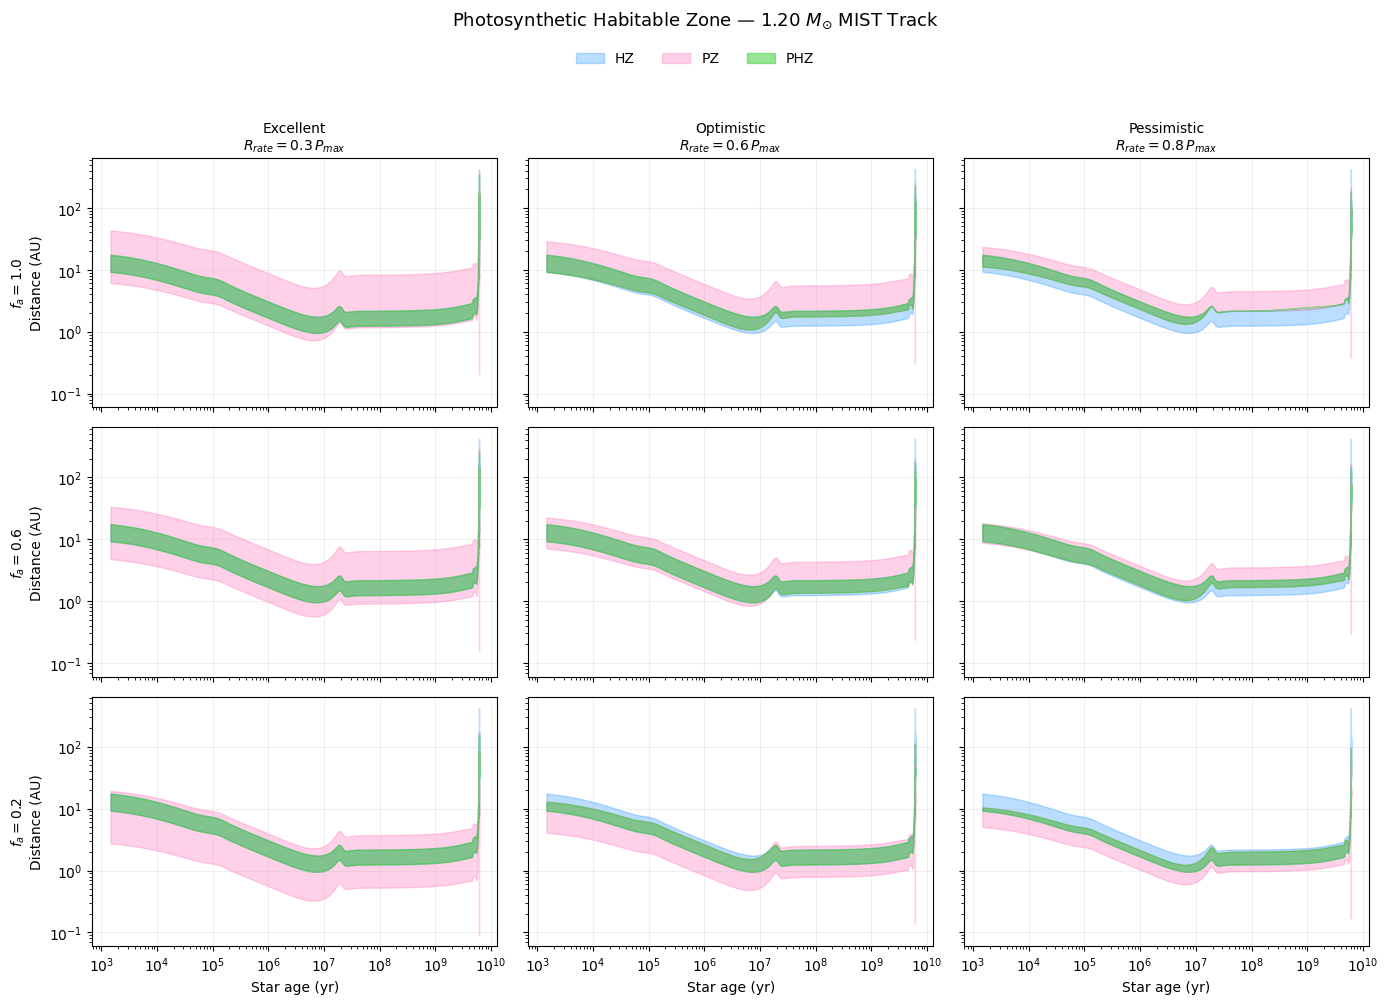

In [22]:
df_plot = tracks_phz["1.20 M☉"] 
t = df_plot["star_age"].to_numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for row, f_a in enumerate(f_as):
    for col, (R_rate, rlabel) in enumerate(zip(R_rates, R_rate_labels)):
        ax = axes[row, col]
        tag = f"fa{f_a}_Rr{R_rate}"
        
        #  HZ boundaries (conservative: Runaway GH inner, Max GH outer) 
        hz_in  = df_plot["d_AU_Runaway_Greenhouse"].to_numpy()
        hz_out = df_plot["d_AU_Maximum_Greenhouse"].to_numpy()
        
        #  PZ boundaries 
        pz_in  = df_plot[f"PHZ_inner_{tag}"].to_numpy()
        pz_out = df_plot[f"PHZ_outer_{tag}"].to_numpy()
        
        #  Overlap (PHZ) = max of inner edges to min of outer edges 
        phz_in  = np.maximum(hz_in, pz_in)
        phz_out = np.minimum(hz_out, pz_out)
        # Only valid where inner < outer
        overlap_mask = phz_in < phz_out
        
        # Masks for finite values
        m = np.isfinite(t) & np.isfinite(hz_in) & np.isfinite(hz_out)
        mp = np.isfinite(t) & np.isfinite(pz_in) & np.isfinite(pz_out)
        
        # Plot fills
        ax.fill_between(t[m],  hz_in[m],  hz_out[m],  color="dodgerblue", alpha=0.3, label="HZ")
        ax.fill_between(t[mp], pz_in[mp], pz_out[mp], color="hotpink",    alpha=0.3, label="PZ")
        
        # PHZ overlap
        mo = m & mp & overlap_mask
        if mo.any():
            ax.fill_between(t[mo], phz_in[mo], phz_out[mo], color="limegreen", alpha=0.5, label="PHZ")
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(alpha=0.2)
        
        # Labels on edges only
        if row == 0:
            ax.set_title(f"{rlabel}\n$R_{{rate}} = {R_rate}\,P_{{max}}$", fontsize=10)
        if row == 2:
            ax.set_xlabel("Star age (yr)")
        if col == 0:
            ax.set_ylabel(f"$f_a = {f_a}$\nDistance (AU)", fontsize=10)

# Grab legend from one panel
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=3, frameon=False)

fig.suptitle("Photosynthetic Habitable Zone — 1.20 $M_{\odot}$ MIST Track", y=1.0, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
